## Import

In [116]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as rmse

## Introduction

#### 1. Примеры использования ИИ в жизни
1. Создание систиемы контроля видеокамер на основе компьютерного зрения. Автономное слежение и реагирование по камерам, без постоянного присутствия человека. Снижение рисков по упущению чего-либо важного по камерам.
2. Создание голосового помощника (как у железного человека). Автоматизация команд и действий, разделение зон внимания за счет отдачи некоторых действий ассистенту.
3. Беспилотные автомобили. Снижение рисков, связанных с ухудшением внимания водителей на дороге, контроль движения по полосам может спасити при сне за рулем или внезапном обострении заболевания водителя.
4. Анализ медицинских документов. Подсвечивание подозрительных областей на сниках или в анамнезе, помощь врачу. Заполнение документации - автоматизация процессов лечения, позволяет врачу сосредоточиться на лечении
5. Перевод текста. В реальном времени переводит что-либо - текст, видео... Стирает языковые барьеры
6. Копилот. Подсказки в чем-либо - кодинге, играх и тп. Можно сделать для обучения чего-либо, как микро-учитель.

---

#### 2. Классификация задач по их типу (классификация или регрессия, с учителем или без)

1.	***Спрогнозируйте цену дома***

    Задача регрессии (обучение с учителем)


2.	***Предскажите, вернёт ли клиент кредит***

    Задача классификации (обучение с учителем)


3.	***Прогнозирование времени приёма лекарств пациентом***

    Задача регрессии (обучение с учителем)


4.	***Выберите, какое из доступных лекарств следует дать пациенту***

    Задача классификации (обучение с учителем)


5.	***Выберите сегмент клиентов для рекламной коммуникации***

    Задача классификации (обучение с учителем)


6.	***Распознавание бракованной продукции на производственной линии (на основе фотосканов)***

    Задача классификации (обучение с учителем)


7.	***Решите, как разместить товары на полке в магазине***

    Задача классификации (обучение с учителем) / обучние с подкреплением? 


8.	***Поиск сайтов для ввода текстового запроса***

    Задача классификации (обучение с учителем)


9.	***Разделите клиентов магазина на сегменты, чтобы понять, чем отличается их поведение***

    Задача кластеризации (обучение без учителя)


10.	***Обнаружение аномалий в трафике сайта***

    Задача классификации (обучение с учителем)

---


1. ***Создание систиемы контроля видеокамер на основе компьютерного зрения. Автономное слежение и реагирование по камерам, без постоянного присутствия человека. Снижение рисков по упущению чего-либо важного по камерам.***

    Это CV (computer vision)


2. ***Создание голосового помощника (как у железного человека). Автоматизация команд и действий, разделение зон внимания за счет отдачи некоторых действий ассистенту.***

    NLP (natural language processing)+обучение с подкреплением


3. ***Беспилотные автомобили. Снижение рисков, связанных с ухудшением внимания водителей на дороге, контроль движения по полосам может спасити при сне за рулем или внезапном обострении заболевания водителя.***

    CV+обучение с подкреплением


4. ***Анализ медицинских документов. Подсвечивание подозрительных областей на сниках или в анамнезе, помощь врачу. Заполнение документации - автоматизация процессов лечения, позволяет врачу сосредоточиться на лечении***

    CV+NLP


5. ***Перевод текста. В реальном времени переводит что-либо - текст, видео... Стирает языковые барьеры***

    NLP


6. ***Копилот. Подсказки в чем-либо - кодинге, играх и тп. Можно сделать для обучения чего-либо, как микро-учитель.***

    llm\обучение с подкреплением

---

#### 3. В чём разница между мультиклассовым и мультилейблевым обучением

И в мультиклассовой и в мультилейбловой классификации имеются несколько вероятных классов.

Основное отличие мультиклассовой от лейбловой в том, что мультиклассовая классификация возвращает один вероятный класс, а мультилейбловая может относить анализируемый объект к разным классам. Т.е. в мультиклассовой классификации - взаимоисключающие класса, а в мультилейбловой нет.

**Пример:**

*Мультиклассовая классификация:*

    Определить, к какому классу (собака, кошка, лошадь) относится животное на картинке. Животное не может быть разных видов -> можно отнести только к одному классу с какой-то вероятностью 

*Мультилейбловая классификация:*

    На изображении есть: Ночная дорога, по которой едет авто

    Модель определяет это по следующим классам. ['Ночь': 1, 'Дорога': 1, 'Автомобиль': 1, 'Дерево': 0]

    Вторая картинка: Дерево в саду

    Модель определяет это по следующим классам. ['Ночь': 0, 'Дорога': 0, 'Автомобиль': 0, 'Дерево': 1]

---

#### 4. Задача, которая рассматривается в этом задании - задача классификации или регресси?

Это скорее задача регрессии, тк таргет-поле - это цена жилья, а не категориальное значение.

В определенных случаях задачу регрессии можно представить в виде классификации. Например определить классы "Дорогое жилье", "Жилье средней цены", "Жилье по низкой цене", разделив их по определенным диапазонам, и предсказывать уже их.

## Introduction to Data Analysis

In [117]:
train = pd.read_json('data/train.json')
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [118]:
train.select_dtypes(include=['int64', 'float64']).corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [119]:
train.describe().round(1)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.0,49352.0,49352.0,49352.0,49352.0,49352.0
mean,1.2,1.5,40.7,7024054.7,-74.0,3830.2
std,0.5,1.1,0.6,126274.6,1.2,22066.9
min,0.0,0.0,0.0,6811957.0,-118.3,43.0
25%,1.0,1.0,40.7,6915887.5,-74.0,2500.0
50%,1.0,1.0,40.8,7021070.5,-74.0,3150.0
75%,1.0,2.0,40.8,7128733.2,-74.0,4100.0
max,10.0,8.0,44.9,7753784.0,0.0,4490000.0


In [120]:
train.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [121]:
train = train[['bathrooms', 'bedrooms', 'interest_level', 'price']]

Мы можем видеть, что в базе всего 49352 строк и 15 полей

Пустых строк нет

Целевым полем является цена (price), величина которой варьируется от 43 до 4.490.000 долларов и увеличивается с повышением количества спален (от 0 до 10) и ванных (от0 до 10) комнат. Стандартное отклонение цен - 22066, а также медиана (3150), которая меньше, чем среднее арифметическое (3830), дают понять, что цены сильно разнятся в большую сторону, вероятно есть выбросы

<Axes: xlabel='price', ylabel='Count'>

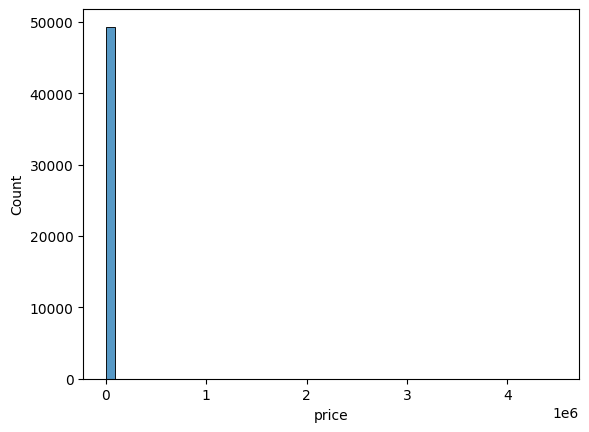

In [122]:
sns.histplot(data=train, x='price', bins=50)

<Axes: xlabel='price'>

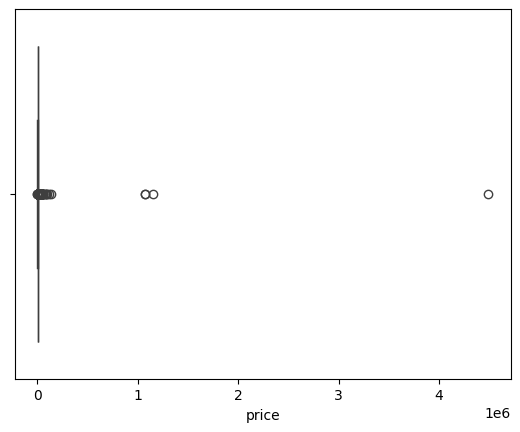

In [123]:
sns.boxplot(data=train, x='price')

In [124]:
train = train[(train['price'] < train['price'].quantile(0.99)) & (train['price'] > train['price'].quantile(0.01))]
train

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


<Axes: xlabel='price', ylabel='Count'>

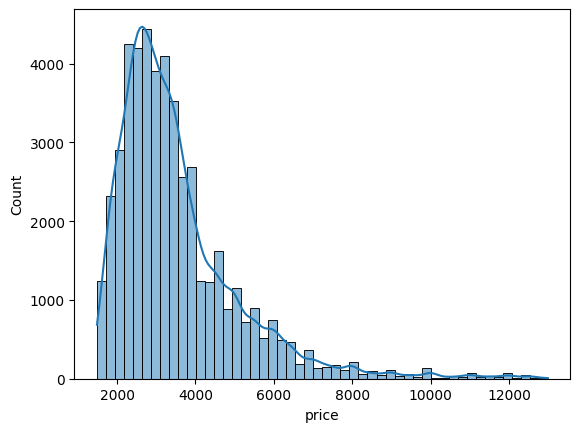

In [125]:
sns.histplot(data=train, x='price', bins=50, kde=True)

<Axes: xlabel='bathrooms', ylabel='Count'>

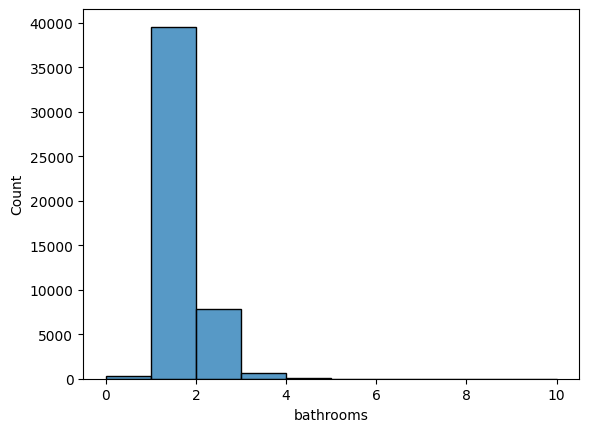

In [126]:
sns.histplot(data=train, x='bathrooms', bins=10)

<Axes: xlabel='bedrooms', ylabel='Count'>

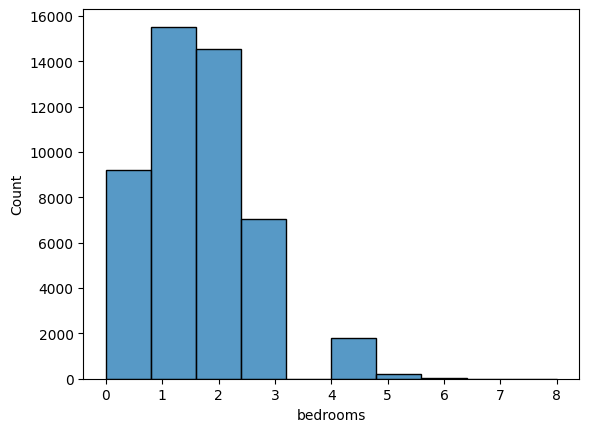

In [127]:
sns.histplot(data=train, x='bedrooms', bins=10)

In [128]:
train['interest_level'].info()
train['interest_level'].value_counts()

<class 'pandas.core.series.Series'>
Index: 48343 entries, 4 to 124009
Series name: interest_level
Non-Null Count  Dtype 
--------------  ----- 
48343 non-null  object
dtypes: object(1)
memory usage: 755.4+ KB


interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

In [129]:
train.loc[:,'interest_level'] = train['interest_level'].map({'low':0, 'medium':1, 'high':2})

<Axes: >

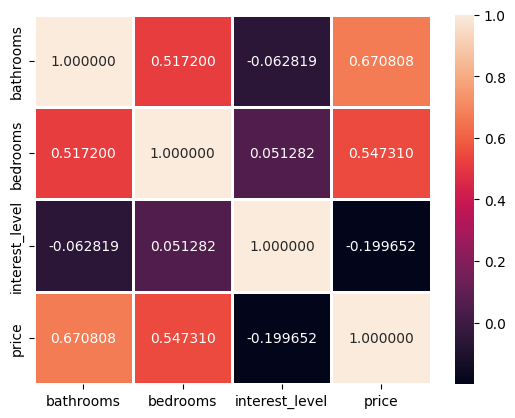

In [130]:
corr = train.corr()
sns.heatmap(corr, annot=True, linewidths=1, fmt='.6f')

Text(0.5, 1.0, 'Interest_level')

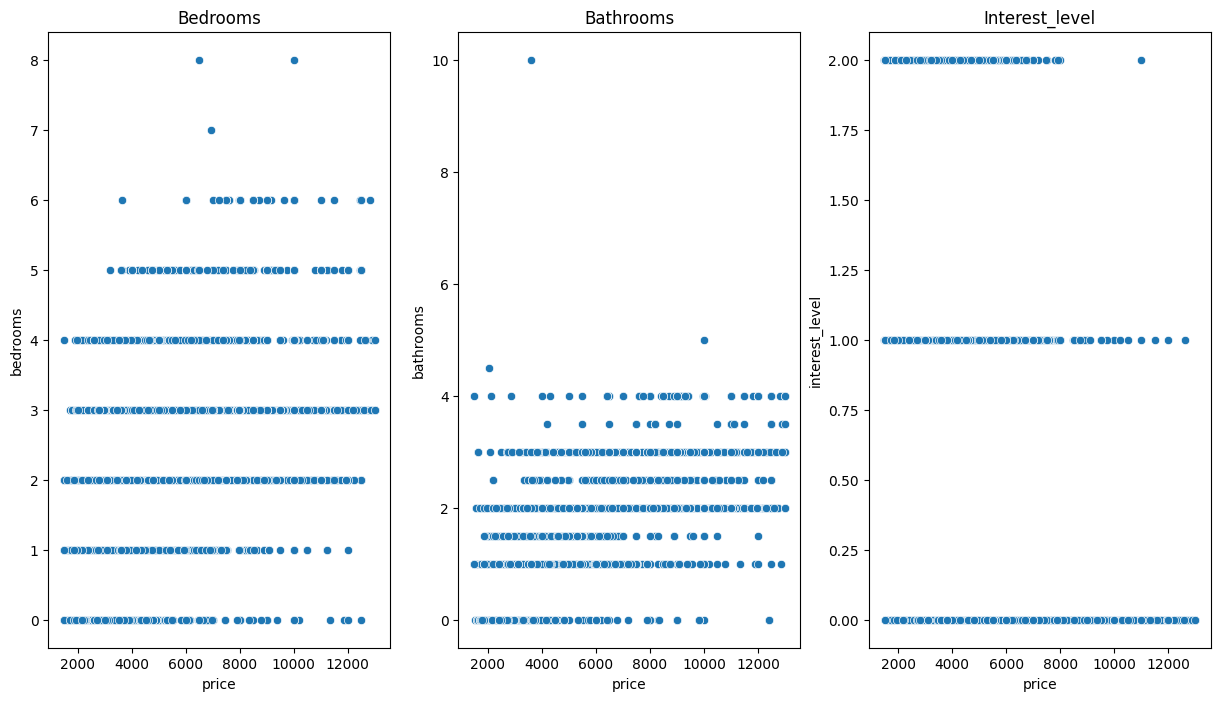

In [131]:
fig, ax = plt.subplots(1,3,figsize=(15,8))
sns.scatterplot(data=train, x='price', y='bedrooms', ax = ax[0])
ax[0].set_title('Bedrooms')
sns.scatterplot(data=train, x='price', y='bathrooms', ax = ax[1])
ax[1].set_title('Bathrooms')
sns.scatterplot(data=train, x='price', y='interest_level', ax = ax[2])
ax[2].set_title('Interest_level')

In [132]:
new_df = pd.DataFrame({
    'square_bathrooms': np.square(train['bathrooms']),
    'square_bedrooms': np.square(train['bedrooms']),
    'square_interest_level': np.square(train['interest_level'])
})
square_corr = pd.concat([train,new_df], axis=1)

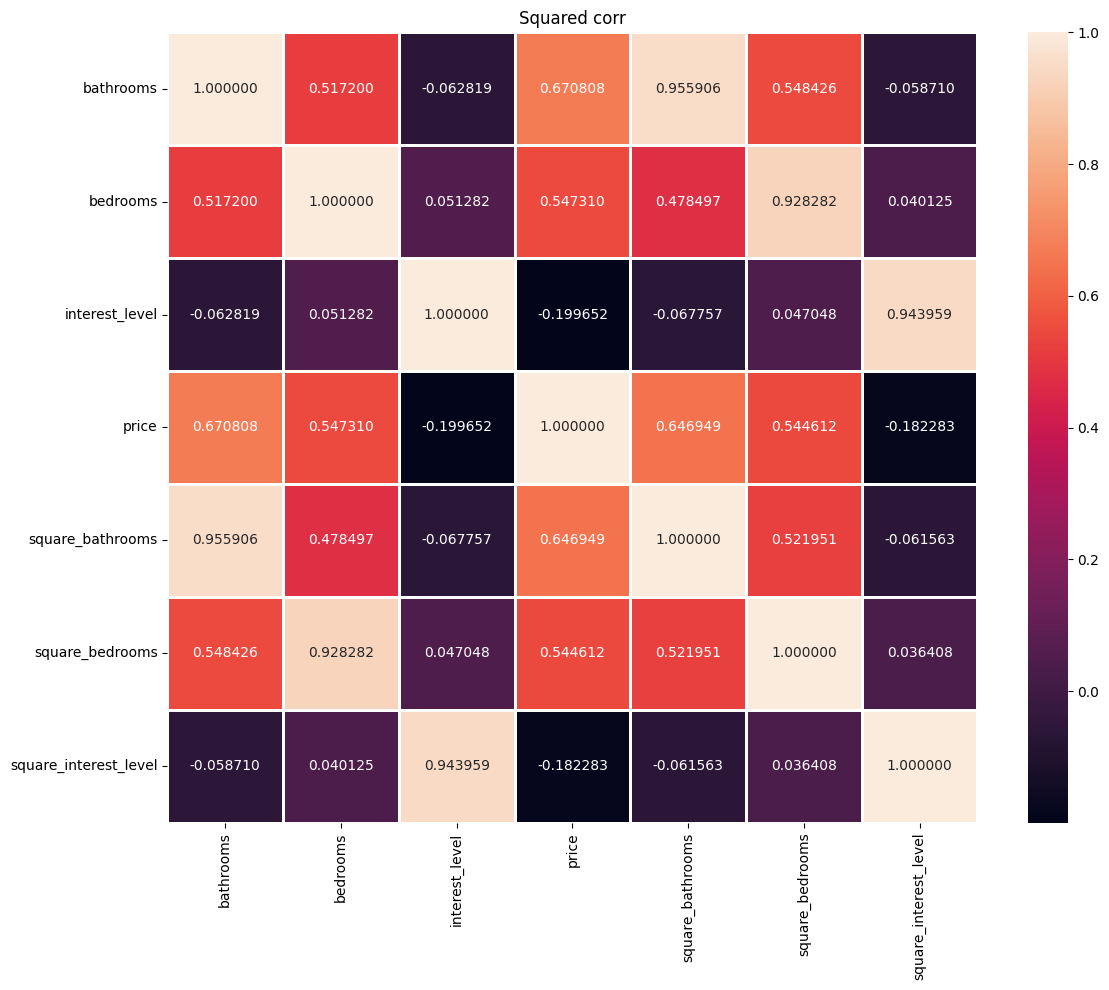

In [133]:
corrnew = square_corr.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corrnew, annot=True, linewidths=1, fmt='.6f')
plt.title('Squared corr')
plt.tight_layout()

In [ ]:
test = pd.read_json('data/test.json')
test = test[['bedrooms', 'bathrooms', 'price']]
test = test[(test['price'] < test['price'].quantile(0.99)) & (test['price'] > test['price'].quantile(0.01))]

In [135]:
X_train = train[['bedrooms', 'bathrooms']]
y_train = train['price']
X_test = test[['bedrooms','bathrooms']]
y_test = test['price']
result_MAE = pd.DataFrame(columns=['model','train','test']).astype({'model':'object','train':'float64','test':'float64'})
result_RMSE = pd.DataFrame(columns=['model','train','test']).astype({'model':'object','train':'float64','test':'float64'})

In [136]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [ ]:
def concatenate(result, model, type, train_pred, test_pred):
    """Добавление метрик моделей в таблицу"""
    result = pd.concat([
        result,
        pd.DataFrame({
            'model': [model],
            'train': [mae(y_train, train_pred)] if type == 'mae' else [np.sqrt(rmse(y_train, train_pred))],
            'test':[mae(y_test, test_pred)] if type == 'mae' else [np.sqrt(rmse(y_test, test_pred))]
            })
        ], ignore_index=True)
    return result

In [138]:
linreg = LinearRegression().fit(X_poly_train, y_train)

train_pred = linreg.predict(X_poly_train)
test_pred = linreg.predict(X_poly_test)

result_MAE = concatenate(result_MAE, 'LinearRegression', 'mae', train_pred, test_pred)
result_RMSE = concatenate(result_RMSE, 'LinearRegression', 'rmse', train_pred, test_pred)

In [139]:
decision = DecisionTreeRegressor(random_state=21).fit(X_poly_train, y_train)

train_pred = decision.predict(X_poly_train)
test_pred = decision.predict(X_poly_test)

result_MAE = concatenate(result_MAE, 'DecisionTreeRegressor', 'mae', train_pred, test_pred)
result_RMSE = concatenate(result_RMSE, 'DecisionTreeRegressor', 'rmse', train_pred, test_pred)

In [140]:
dummy = DummyRegressor(strategy='median').fit(X_poly_train, y_train)

train_pred = dummy.predict(X_poly_train)
test_pred = dummy.predict(X_poly_test)

result_MAE = concatenate(result_MAE, 'naive_median', 'mae', train_pred, test_pred)
result_RMSE = concatenate(result_RMSE, 'naive_median', 'rmse', train_pred, test_pred)

In [141]:
dummy = DummyRegressor(strategy='mean').fit(X_poly_train, y_train)

train_pred = dummy.predict(X_poly_train)
test_pred = dummy.predict(X_poly_test)

result_MAE = concatenate(result_MAE, 'naive_mean', 'mae', train_pred, test_pred)
result_RMSE = concatenate(result_RMSE, 'naive_mean', 'rmse', train_pred, test_pred)

In [142]:
result_MAE

,model,train,test
0,LinearRegression,779.013656,802.851514
1,DecisionTreeRegressor,753.675997,756.112738
2,naive_median,1082.220859,1078.672733
3,naive_mean,1134.361473,1130.888160


In [143]:
result_RMSE

,model,train,test
0,LinearRegression,1114.455172,5841.821701
1,DecisionTreeRegressor,1070.598967,1072.051550
2,naive_median,1631.719953,1617.915709
3,naive_mean,1585.609099,1573.238184


Лучшей моделью по данным метрикам является DecisionTreeRegressor потому, что имеет наименьшие MAE и RMSE, а также не показывает сильных значений переобучения